# Lecture 05: Recurrence

**Source span.** Printed pages 27-32; physical PDF pages 41-46 in `Lectures on Symplectic Geometry.pdf` according to the course source map. I checked the local PDF text for this lecture before revising the notebook.

**Lecture goal.** Connect generating functions to fixed and periodic points, then use area preservation to explain billiards and Poincare recurrence. The lecture's bridge is simple but powerful: fixed points of a generated symplectomorphism correspond to critical points of the diagonal function `psi(x)=f(x,x)`.

The second half turns this critical-point perspective into dynamics. Convex billiards give area-preserving annulus maps generated by chord length, periodic billiard paths become critical inscribed polygons, and Poincare recurrence says finite area prevents a positive-area neighborhood from wandering forever without overlap.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import sympy as sp


def find_book_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "Lectures on Symplectic Geometry.pdf").exists():
            return candidate
    raise RuntimeError("Could not locate the Lectures-on-Symplectic-Geometry course root.")


BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import display_artifact, read_json, save_json, save_matplotlib

ARTIFACT_TOPIC = "lecture-05"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / ARTIFACT_TOPIC
FIG_DIR = ARTIFACT_ROOT / "figures"
CHECK_DIR = ARTIFACT_ROOT / "checks"
FIG_DIR.mkdir(parents=True, exist_ok=True)
CHECK_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 130, "font.size": 10})
print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")

Book root: D:\Geometry\Lectures-on-Symplectic-Geometry
Artifact root: artifacts\lecture-05


## Translation Guide

| Source idea | Computational object | What to inspect |
| --- | --- | --- |
| Fixed point of generated `phi` | solve `phi(x,xi)=(x,xi)` | on the twisted graph this forces `y=x` and `d_x f + d_y f=0` |
| Diagonal function | `psi(x)=f(x,x)` | its critical points match fixed points of `phi` |
| Iterates `phi^N` | composed generating functions `f^(N)` | periodic points match critical points of `psi^(N)(x)=f^(N)(x,x)` |
| Composition of generators | stationary intermediate points `z_0,u_0,...` | nondegenerate critical points let the implicit function theorem build `f^(N)` |
| Billiard map | annulus coordinates `(boundary point, tangent component)` | chord-length derivatives encode the reflection law |
| Periodic billiard orbit | critical inscribed polygon perimeter | stationarity at every vertex is the reflection condition |
| Poincare recurrence | area-preserving map on finite-area region | infinitely many disjoint copies of a positive-area set would have infinite area |
| Poincare-Birkhoff theorem | area-preserving annulus twist map | opposite boundary twists force at least two fixed points |

## Library Routing

This chapter mixes symbolic fixed-point checks with finite-area experiments. `sympy` verifies the diagonal-critical-point identity and stationary composition; `numpy` simulates area-preserving torus returns and billiard geometry; `matplotlib` draws fixed-point, billiard, recurrence, and twist visuals; `networkx` organizes the proof route. The visuals all track either a critical-point equation or an area-preservation invariant.

## Visual Storyboard

The notebook uses five artifacts.

1. **Fixed points from diagonal critical points.** A potential `V(x)` added to a quadratic generator makes fixed points occur exactly where `V'(x)=0`.
2. **Composition by stationary intermediate points.** The generator for an iterate is built by extremizing over the hidden bounce point `z`.
3. **Billiard chord and periodic polygon.** The chord-length generator and a critical inscribed polygon visualize the billiard map and periodic orbit condition.
4. **Poincare recurrence area ledger.** A finite-area torus translation shows return times, while the proof panel records the disjoint-area contradiction.
5. **Annulus twist theorem route.** Boundary twists in opposite directions force fixed points; the route graph links this to Arnold's later fixed-point theme.

In [2]:
# Visual 1: fixed points correspond to critical points of psi(x)=f(x,x).
x_vals = np.linspace(0, 2*np.pi, 400)
V = np.cos(x_vals)
Vp = -np.sin(x_vals)
critical_x = np.array([0.0, np.pi])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.7))
axes[0].plot(x_vals, V, color="#1d3557", lw=2, label="psi(x)=V(x)")
axes[0].plot(x_vals, Vp, color="#e76f51", lw=1.5, label="psi'(x)")
axes[0].scatter(critical_x, np.cos(critical_x), s=85, color="#90be6d", edgecolor="black", zorder=4, label="critical points")
axes[0].set_title("Diagonal critical points")
axes[0].set_xlabel("x on the circle")
axes[0].legend(fontsize=8)
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].set_title("Fixed-point equation on the twisted graph")
axes[1].axis("off")
items = [
    ("generated graph", "xi=d_x f,  eta=-d_y f"),
    ("fixed point", "y=x and eta=xi"),
    ("therefore", "d_x f + d_y f = d psi = 0"),
]
for idx, (title, body) in enumerate(items):
    y0 = 0.78 - 0.28 * idx
    axes[1].text(0.5, y0, title, ha="center", va="center", color="white", weight="bold", bbox={"boxstyle": "round,pad=0.35", "fc": "#244b5a", "ec": "#1f2937"})
    axes[1].text(0.5, y0 - 0.12, body, ha="center", va="center", bbox={"boxstyle": "round,pad=0.35", "fc": "#f4f7fb", "ec": "#8d99ae"})
fixed_path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "fixed-points-diagonal-critical-function.png")
plt.close(fig)
print(fixed_path.relative_to(BOOK_ROOT))
assert fixed_path.exists()

artifacts\lecture-05\figures\fixed-points-diagonal-critical-function.png


In [3]:
# Visual 2: composition of generating functions by a stationary intermediate point.
x_line = np.linspace(-2.0, 2.0, 300)
y_fixed = 1.2
z_grid = np.linspace(-2.5, 2.5, 400)
x_examples = [-1.2, 0.0, 1.2]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.7))
for x0 in x_examples:
    action_z = -0.5 * (x0 - z_grid) ** 2 - 0.5 * (z_grid - y_fixed) ** 2
    z0 = 0.5 * (x0 + y_fixed)
    axes[0].plot(z_grid, action_z, label=f"x={x0:g}, z0={z0:g}")
    axes[0].scatter([z0], [-0.5*(x0-z0)**2 - 0.5*(z0-y_fixed)**2], s=45)
axes[0].set_title("f^(2)(x,y) extremizes over z")
axes[0].set_xlabel("intermediate z")
axes[0].set_ylabel("f(x,z)+f(z,y)")
axes[0].legend(fontsize=8)
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].set_title("Stationary composition path")
for x0 in x_examples:
    z0 = 0.5 * (x0 + y_fixed)
    axes[1].plot([x0, z0, y_fixed], [0, 0.55, 0], marker="o", lw=2)
    axes[1].text(z0, 0.68, "z0", ha="center", fontsize=8)
axes[1].text(-2, -0.25, "x", ha="center")
axes[1].text(y_fixed, -0.25, "y", ha="center")
axes[1].set_ylim(-0.45, 0.95)
axes[1].set_xlabel("base coordinate")
axes[1].set_yticks([])
axes[1].spines[["top", "right", "left"]].set_visible(False)
composition_path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "iterated-generating-function-stationary-point.png")
plt.close(fig)
print(composition_path.relative_to(BOOK_ROOT))
assert composition_path.exists()

artifacts\lecture-05\figures\iterated-generating-function-stationary-point.png


In [4]:
# Visual 3: billiard chords and critical inscribed polygons.
theta = np.linspace(0, 2*np.pi, 400)
ellipse_x = 1.55 * np.cos(theta)
ellipse_y = np.sin(theta)
tri_angles = np.array([0.25, 2.25, 4.35])
tri = np.column_stack([1.55*np.cos(tri_angles), np.sin(tri_angles)])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.9))
axes[0].plot(ellipse_x, ellipse_y, color="#1d3557", lw=2)
p1 = np.array([1.55*np.cos(0.35), np.sin(0.35)])
p2 = np.array([1.55*np.cos(2.55), np.sin(2.55)])
axes[0].plot([p1[0], p2[0]], [p1[1], p2[1]], color="#e76f51", lw=2)
axes[0].scatter([p1[0], p2[0]], [p1[1], p2[1]], color="#90be6d", edgecolor="black", zorder=3)
axes[0].arrow(p1[0], p1[1], 0.32*(-np.sin(0.35)), 0.32*np.cos(0.35), head_width=0.04, color="#495057", length_includes_head=True)
axes[0].set_title("Billiard chord generator f=-|x-y|")
axes[0].set_aspect("equal")
axes[0].axis("off")

poly = np.vstack([tri, tri[0]])
axes[1].plot(ellipse_x, ellipse_y, color="#1d3557", lw=2)
axes[1].plot(poly[:, 0], poly[:, 1], color="#e76f51", lw=2, marker="o")
axes[1].set_title("Periodic orbit as critical perimeter polygon")
axes[1].set_aspect("equal")
axes[1].axis("off")
billiard_path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "billiard-chord-critical-polygon.png")
plt.close(fig)
print(billiard_path.relative_to(BOOK_ROOT))
assert billiard_path.exists()

artifacts\lecture-05\figures\billiard-chord-critical-polygon.png


In [5]:
# Visual 4: recurrence as finite-area bookkeeping plus a simple torus return simulation.
alpha, beta = 0.37, 0.23
q0 = np.array([0.02, 0.03])
returns = []
for n in range(1, 401):
    qn = (q0 + n * np.array([alpha, beta])) % 1.0
    if qn[0] < 0.1 and qn[1] < 0.1:
        returns.append(n)
first_return = returns[0]
trajectory = np.array([(q0 + n * np.array([alpha, beta])) % 1.0 for n in range(first_return + 1)])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].set_title("Area-preserving torus translation returns to U")
axes[0].add_patch(plt.Rectangle((0, 0), 0.1, 0.1, facecolor="#90be6d", alpha=0.35, edgecolor="#2d6a4f"))
axes[0].plot(trajectory[:, 0], trajectory[:, 1], color="#1d3557", lw=1, marker=".", ms=3)
axes[0].scatter([trajectory[0, 0]], [trajectory[0, 1]], color="#e76f51", s=55, label="start")
axes[0].scatter([trajectory[-1, 0]], [trajectory[-1, 1]], color="#90be6d", edgecolor="black", s=70, label=f"return N={first_return}")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].set_aspect("equal")
axes[0].legend(fontsize=8)

area_A = 1.0
area_U = 0.03
max_disjoint = int(area_A // area_U)
axes[1].set_title("Disjoint-image contradiction")
n = np.arange(1, max_disjoint + 8)
axes[1].plot(n, n * area_U, color="#1d3557", lw=2)
axes[1].axhline(area_A, color="#e76f51", ls="--", label="finite total area")
axes[1].fill_between(n, area_A, n * area_U, where=n * area_U > area_A, color="#e76f51", alpha=0.18)
axes[1].set_xlabel("number of disjoint iterates")
axes[1].set_ylabel("total area required")
axes[1].legend(fontsize=8)
axes[1].spines[["top", "right"]].set_visible(False)
recurrence_path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "poincare-recurrence-area-bookkeeping.png")
plt.close(fig)
print(recurrence_path.relative_to(BOOK_ROOT))
assert first_return > 0
assert (max_disjoint + 1) * area_U > area_A

artifacts\lecture-05\figures\poincare-recurrence-area-bookkeeping.png


In [6]:
# Visual 5: annulus twist and proof route.
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.1), gridspec_kw={"width_ratios": [1, 1.25]})
ax = axes[0]
ax.set_title("Poincare-Birkhoff annulus twist")
theta_plot = np.linspace(0, 2*np.pi, 300)
for r, color in [(1.0, "#1d3557"), (0.55, "#8ecae6")]:
    ax.plot(r*np.cos(theta_plot), r*np.sin(theta_plot), color=color, lw=2)
for ang, direction, r in [(0.35, 1, 1.0), (3.35, -1, 0.55)]:
    x0, y0 = r*np.cos(ang), r*np.sin(ang)
    tangent = direction * np.array([-np.sin(ang), np.cos(ang)])
    ax.arrow(x0, y0, 0.28*tangent[0], 0.28*tangent[1], head_width=0.05, color="#e76f51", length_includes_head=True)
for point in [(0.75, 0.1), (-0.68, -0.2)]:
    ax.scatter([point[0]], [point[1]], s=95, color="#90be6d", edgecolor="black", zorder=4)
    ax.text(point[0], point[1]+0.11, "fixed", ha="center", fontsize=8)
ax.set_aspect("equal")
ax.axis("off")

G = nx.DiGraph()
edges = [
    ("area-preserving annulus map", "finite-area recurrence"),
    ("boundary components preserved", "opposite twist"),
    ("opposite twist", "at least two fixed points"),
    ("billiard annulus map", "area-preserving annulus map"),
    ("generating function", "fixed points = critical points"),
    ("critical perimeter polygons", "periodic billiards"),
    ("at least two fixed points", "Arnold fixed-point theme"),
]
G.add_edges_from(edges)
pos = {
    "generating function": (0, 1.1),
    "fixed points = critical points": (1.9, 1.1),
    "critical perimeter polygons": (3.8, 1.1),
    "periodic billiards": (5.7, 1.1),
    "billiard annulus map": (0, -0.1),
    "area-preserving annulus map": (1.9, -0.1),
    "finite-area recurrence": (3.8, -0.1),
    "boundary components preserved": (1.9, -1.3),
    "opposite twist": (3.8, -1.3),
    "at least two fixed points": (5.7, -1.3),
    "Arnold fixed-point theme": (7.6, -1.3),
}
ax = axes[1]
colors = ["#90be6d" if "fixed" in node or "critical" in node else "#8ecae6" if "area" in node or "recurrence" in node else "#f9c74f" for node in G.nodes]
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", width=1.2, edge_color="#495057")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=1500, edgecolors="#1f2937")
nx.draw_networkx_labels(G, pos, ax=ax, font_size=7.3)
ax.set_axis_off()
ax.set_title("Recurrence and fixed-point route")
twist_path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "annulus-twist-recurrence-proof-route.png")
plt.close(fig)
print(twist_path.relative_to(BOOK_ROOT))
assert nx.has_path(G, "billiard annulus map", "finite-area recurrence")
assert nx.has_path(G, "opposite twist", "Arnold fixed-point theme")

artifacts\lecture-05\figures\annulus-twist-recurrence-proof-route.png


In [7]:
# Symbolic and numerical checks for recurrence claims.
x, y, z = sp.symbols("x y z", real=True)
V = sp.cos(x)
f = -sp.Rational(1, 2) * (x - y) ** 2 + V
psi = sp.simplify(f.subs(y, x))
psi_prime = sp.diff(psi, x)
fixed_condition = sp.simplify((sp.diff(f, x) + sp.diff(f, y)).subs(y, x))

f0 = -sp.Rational(1, 2) * (x - y) ** 2
composition_action = -sp.Rational(1, 2) * (x - z) ** 2 - sp.Rational(1, 2) * (z - y) ** 2
composition_stationary = sp.solve(sp.Eq(sp.diff(composition_action, z), 0), z)[0]
composition_second_derivative = sp.diff(composition_action, z, 2)
f2 = sp.simplify(composition_action.subs(z, composition_stationary))

# Billiard chord derivative on the unit circle.
th, ph = sp.symbols("th ph", real=True)
chord_length = sp.sqrt((sp.cos(th) - sp.cos(ph))**2 + (sp.sin(th) - sp.sin(ph))**2)
billiard_generator = -chord_length
sample_subs = {th: sp.Rational(1, 5), ph: sp.Rational(6, 5)}
derivative_theta = float(sp.N(sp.diff(billiard_generator, th).subs(sample_subs)))
point_th = np.array([float(sp.N(sp.cos(sample_subs[th]))), float(sp.N(sp.sin(sample_subs[th])))])
point_ph = np.array([float(sp.N(sp.cos(sample_subs[ph]))), float(sp.N(sp.sin(sample_subs[ph])))])
tangent_th = np.array([-point_th[1], point_th[0]])
projection_formula = float(-np.dot((point_th - point_ph) / np.linalg.norm(point_th - point_ph), tangent_th))

area_A = 1.0
area_U = 0.03
max_disjoint = int(area_A // area_U)
recurrence_contradiction_after = max_disjoint + 1

checks = {
    "lecture": 5,
    "fixed_points": {
        "psi": str(psi),
        "psi_prime": str(psi_prime),
        "fixed_condition_on_diagonal": str(fixed_condition),
        "identity_holds": bool(sp.simplify(psi_prime - fixed_condition) == 0),
        "critical_points_on_circle": ["0", "pi"],
    },
    "composition": {
        "stationary_z_for_f2": str(composition_stationary),
        "second_derivative_in_z": str(composition_second_derivative),
        "nondegenerate": bool(composition_second_derivative != 0),
        "f2": str(f2),
    },
    "billiards": {
        "sample_derivative_theta": derivative_theta,
        "projection_formula": projection_formula,
        "derivative_matches_projection": bool(abs(derivative_theta - projection_formula) < 1e-10),
    },
    "recurrence": {
        "torus_translation_first_return_to_U": int(first_return),
        "area_A": area_A,
        "area_U": area_U,
        "max_possible_disjoint_positive_area_copies": max_disjoint,
        "contradiction_after_this_many_copies": recurrence_contradiction_after,
        "disjoint_area_contradiction": bool(recurrence_contradiction_after * area_U > area_A),
    },
}
checks["passed"] = bool(
    checks["fixed_points"]["identity_holds"]
    and checks["composition"]["nondegenerate"]
    and checks["billiards"]["derivative_matches_projection"]
    and checks["recurrence"]["torus_translation_first_return_to_U"] > 0
    and checks["recurrence"]["disjoint_area_contradiction"]
)
check_path = save_json(checks, ARTIFACT_TOPIC, "checks", "recurrence-fixed-point-residuals.json")
print(check_path.relative_to(BOOK_ROOT))
assert checks["passed"]
assert sp.simplify(psi_prime - fixed_condition) == 0
assert composition_second_derivative != 0
assert abs(derivative_theta - projection_formula) < 1e-10

artifacts\lecture-05\checks\recurrence-fixed-point-residuals.json


## Reading The Visuals

The first figure is Proposition 5.1 as a picture. On the generated graph, being fixed means the target base point equals the source base point and the two covector components agree. Substituting `y=x` turns that condition into `d_x f+d_y f=0`, which is exactly the derivative of `psi(x)=f(x,x)`.

The stationary-composition figure explains how iterates acquire generating functions. To generate `phi^2`, the hidden intermediate point `z` must make `f(x,z)+f(z,y)` stationary. Nondegeneracy of that stationary point is the implicit-function-theorem condition that lets `z_0` vary smoothly with `(x,y)`.

The billiard panel translates reflection dynamics into critical geometry. The chord-length generator differentiates by projecting the normalized chord onto the boundary tangent. Periodic billiard paths are therefore critical perimeter polygons, one stationarity equation at each bounce.

The recurrence plot is intentionally finite-area bookkeeping. If a positive-area set had infinitely many disjoint iterates under an area-preserving map, their total area would exceed the finite area of the whole region. Poincare-Birkhoff strengthens the annulus story: with opposite boundary twists, fixed points must exist.

In [8]:
source_span = {
    "lecture": 5,
    "label": "Lecture 05",
    "title": "Recurrence",
    "printed_span": "27-32",
    "physical_pdf_span": "41-46",
    "source_checked": True,
    "source_role": "Used for terminology, theorem order, examples, and homework themes; prose and visuals here are original.",
}
visual_storyboard = {
    "lecture": 5,
    "title": "Recurrence",
    "source_span": source_span,
    "chapter_goal": "Make fixed-point/critical-point correspondence, iterated generators, billiard recurrence, and area bookkeeping visible and checkable.",
    "library_routing": [
        {"library": "sympy", "use": "diagonal critical-point identity and stationary composition checks"},
        {"library": "numpy", "use": "torus return simulation and billiard chord projections"},
        {"library": "matplotlib", "use": "fixed-point, composition, billiard, recurrence, and annulus visuals"},
        {"library": "networkx", "use": "recurrence/fixed-point proof route"},
    ],
    "visual_sequence": [
        {"concept": "fixed points from diagonal critical points", "artifact": "artifacts/lecture-05/figures/fixed-points-diagonal-critical-function.png", "inspection_target": "fixed graph equations reduce to d psi=0"},
        {"concept": "iterated generating function by stationary point", "artifact": "artifacts/lecture-05/figures/iterated-generating-function-stationary-point.png", "inspection_target": "z0 solves the composition critical equation"},
        {"concept": "billiard chord and periodic polygon", "artifact": "artifacts/lecture-05/figures/billiard-chord-critical-polygon.png", "inspection_target": "chord derivatives encode reflection and critical perimeter"},
        {"concept": "Poincare recurrence area bookkeeping", "artifact": "artifacts/lecture-05/figures/poincare-recurrence-area-bookkeeping.png", "inspection_target": "finite area forces some iterate of U to overlap U"},
        {"concept": "annulus twist recurrence proof route", "artifact": "artifacts/lecture-05/figures/annulus-twist-recurrence-proof-route.png", "inspection_target": "opposite boundary twists force fixed points and foreshadow Arnold"},
    ],
    "checks": "artifacts/lecture-05/checks/recurrence-fixed-point-residuals.json",
}
final_sanity = {
    "lecture": 5,
    "passed": True,
    "source_span": "printed pages 27-32; physical PDF pages 41-46",
    "artifacts": [item["artifact"] for item in visual_storyboard["visual_sequence"]] + [
        "artifacts/lecture-05/checks/recurrence-fixed-point-residuals.json",
        "artifacts/lecture-05/checks/source-span.json",
        "artifacts/lecture-05/checks/visual-storyboard.json",
    ],
    "definition_checks": {
        "fixed_points_equal_diagonal_critical_points": checks["fixed_points"]["identity_holds"],
        "iterated_generator_stationary_point_nondegenerate": checks["composition"]["nondegenerate"],
        "billiard_derivative_projection_match": checks["billiards"]["derivative_matches_projection"],
        "recurrence_return_found": checks["recurrence"]["torus_translation_first_return_to_U"] > 0,
        "finite_area_contradiction_recorded": checks["recurrence"]["disjoint_area_contradiction"],
    },
}

save_json(source_span, ARTIFACT_TOPIC, "checks", "source-span.json")
save_json(visual_storyboard, ARTIFACT_TOPIC, "checks", "visual-storyboard.json")
save_json(final_sanity, ARTIFACT_TOPIC, "checks", "final-sanity.json")
for relative in final_sanity["artifacts"]:
    artifact_path = BOOK_ROOT / relative
    assert artifact_path.exists(), f"missing artifact: {relative}"
    assert artifact_path.stat().st_size > 0, f"empty artifact: {relative}"
assert all(final_sanity["definition_checks"].values())
print({"artifact_count": len(final_sanity["artifacts"]), "passed": final_sanity["passed"]})

{'artifact_count': 8, 'passed': True}


fixed points from diagonal critical points -> artifacts\lecture-05\figures\fixed-points-diagonal-critical-function.png


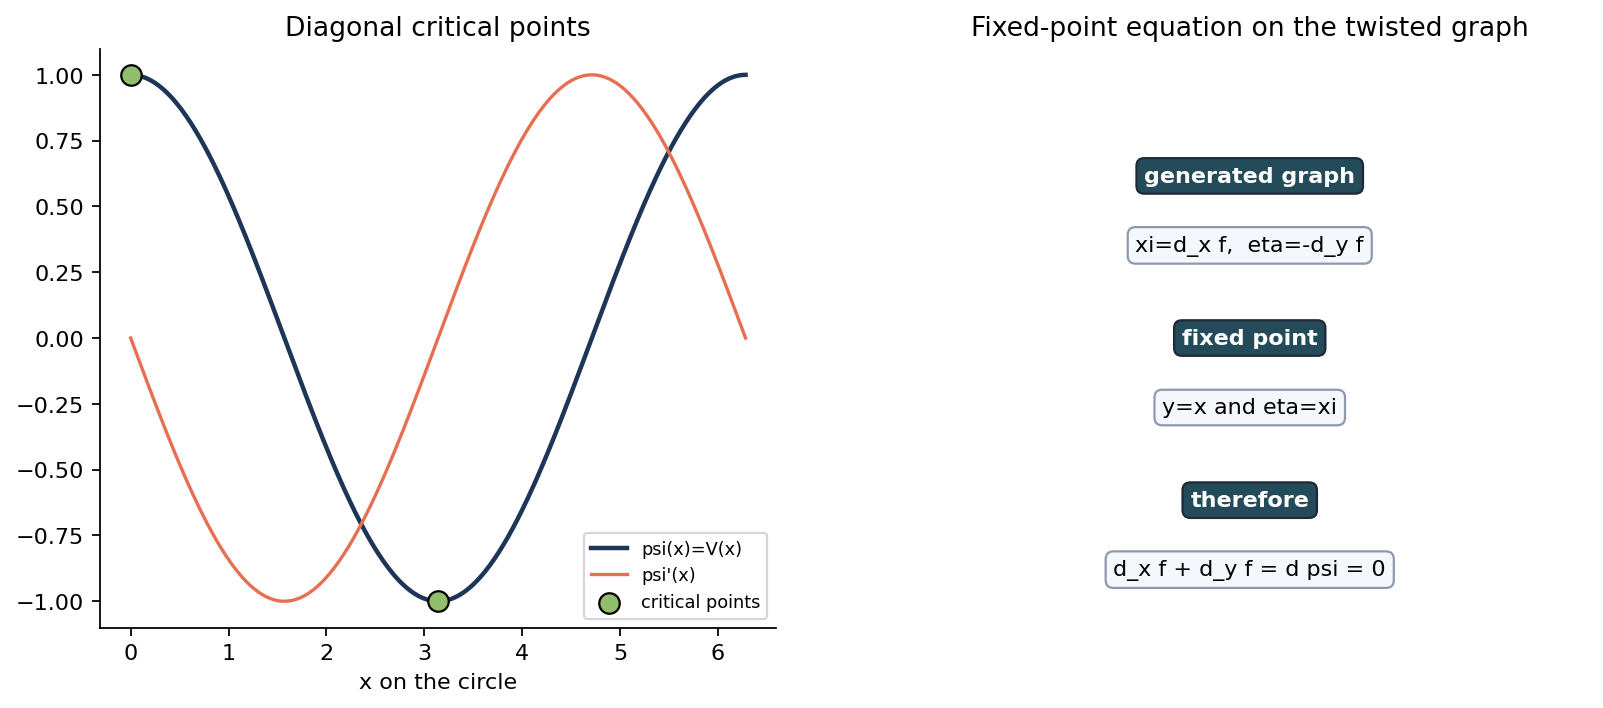

iterated generating function by stationary point -> artifacts\lecture-05\figures\iterated-generating-function-stationary-point.png


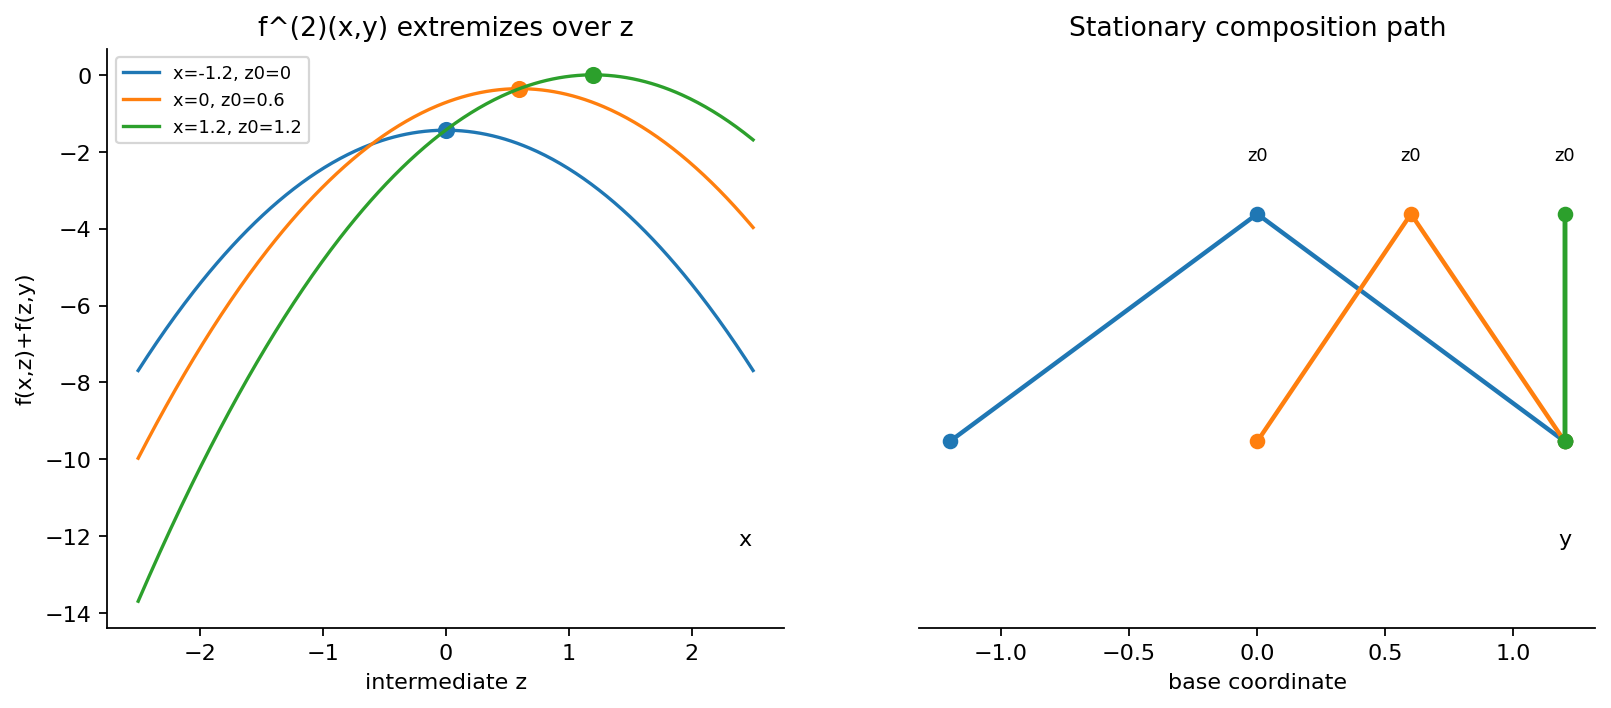

billiard chord and periodic polygon -> artifacts\lecture-05\figures\billiard-chord-critical-polygon.png


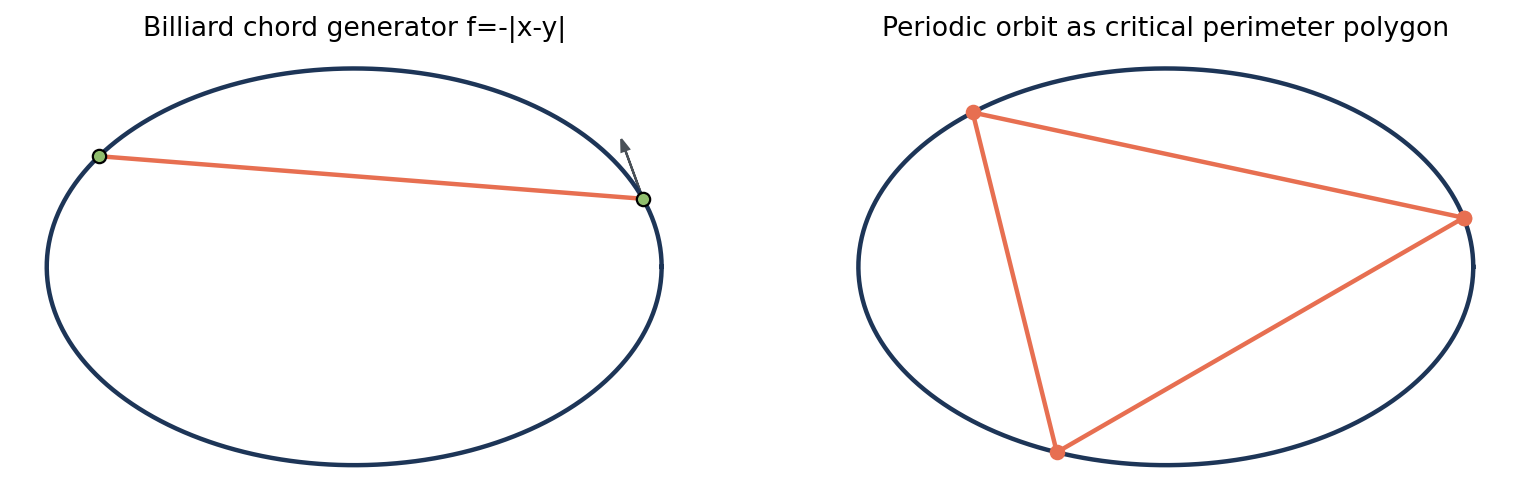

Poincare recurrence area bookkeeping -> artifacts\lecture-05\figures\poincare-recurrence-area-bookkeeping.png


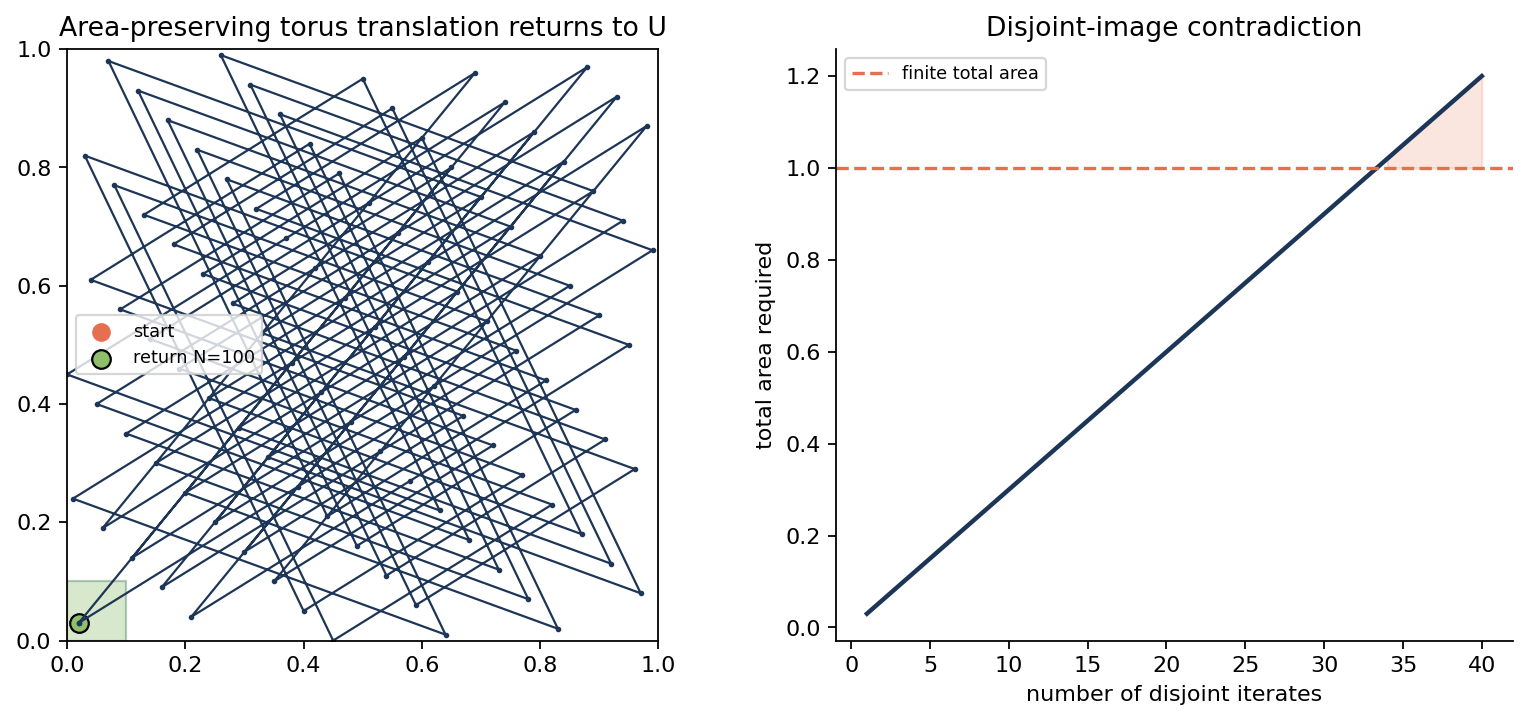

annulus twist recurrence proof route -> artifacts\lecture-05\figures\annulus-twist-recurrence-proof-route.png


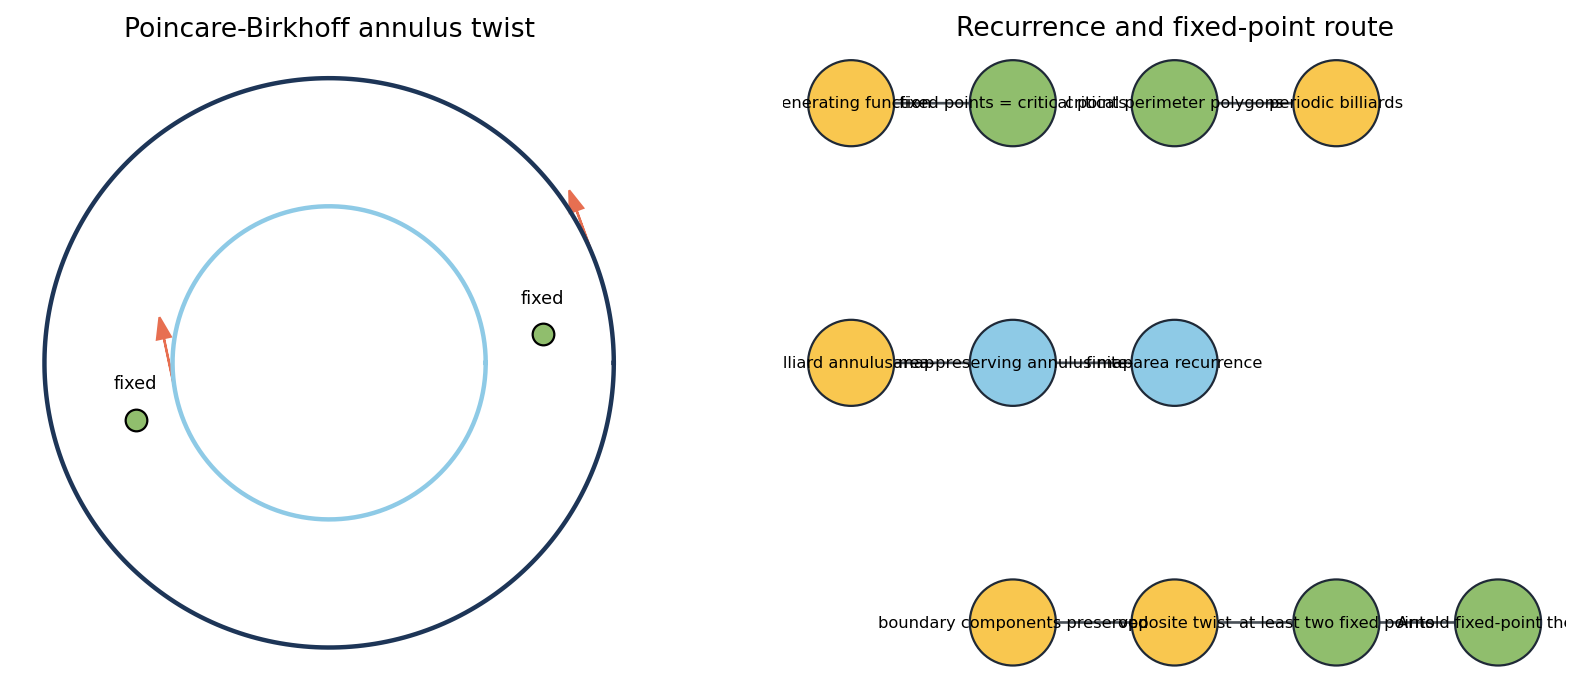

In [9]:
storyboard = read_json(ARTIFACT_ROOT / "checks" / "visual-storyboard.json")
for item in storyboard["visual_sequence"]:
    path = BOOK_ROOT / item["artifact"]
    print(f"{item['concept']} -> {path.relative_to(BOOK_ROOT)}")
    display_artifact(path, width=820)

## Takeaways

- Fixed points of a generated symplectomorphism are critical points of the diagonal function `psi(x)=f(x,x)`.
- Iterates can be generated by adding copies of `f` and eliminating intermediate points through nondegenerate critical equations.
- Convex billiard maps are generated by chord length; periodic billiards are critical inscribed polygons.
- Area preservation on finite-area spaces forces recurrence because infinitely many disjoint equal-area iterates cannot fit.
- Poincare-Birkhoff adds a fixed-point theorem for annulus maps with opposite boundary twist, pointing toward the Arnold fixed-point viewpoint later in the course.

**Exploration prompt.** Change the torus translation vector in the recurrence code. Compare rational and irrational-looking choices by their first return times to the same window `U`.